In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

# Base path
base_path = '/Users/masi/Desktop/Projects/student-early-warning-system/data/raw/'

# Load all datasets
students = pd.read_csv(base_path + 'studentInfo.csv')
assessments = pd.read_csv(base_path + 'assessments.csv')
student_assessments = pd.read_csv(base_path + 'studentAssessment.csv')
student_registration = pd.read_csv(base_path + 'studentRegistration.csv')
student_vle = pd.read_csv(base_path + 'studentVle.csv')
courses = pd.read_csv(base_path + 'courses.csv')
vle = pd.read_csv(base_path + 'vle.csv')

print("All files loaded successfully!")

All files loaded successfully!


In [3]:
# Shape and basic info
print("Shape:", students.shape)
print("\nColumn names:", students.columns.tolist())
print("\nData types:\n", students.dtypes)
print("\nFirst 5 rows:")
students.head()

Shape: (32593, 12)

Column names: ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']

Data types:
 code_module             object
code_presentation       object
id_student               int64
gender                  object
region                  object
highest_education       object
imd_band                object
age_band                object
num_of_prev_attempts     int64
studied_credits          int64
disability              object
final_result            object
dtype: object

First 5 rows:


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


Final Result Distribution:
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

Percentages:
final_result
Pass           37.9
Withdrawn      31.2
Fail           21.6
Distinction     9.3
Name: proportion, dtype: float64


/var/folders/78/fp6ycqwd4n33yk56_4fqw4w00000gn/T/ipykernel_94873/894813050.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=students, x='final_result',


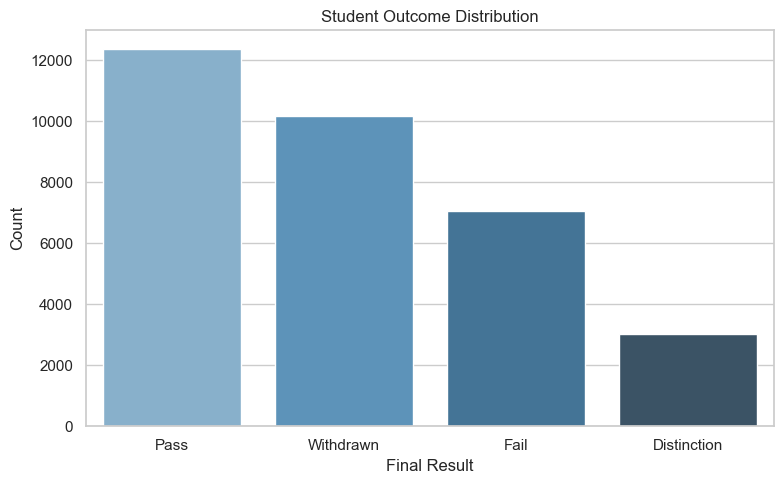

In [4]:
# Check outcome distribution
print("Final Result Distribution:")
print(students['final_result'].value_counts())
print("\nPercentages:")
print(students['final_result'].value_counts(normalize=True).round(3) * 100)

# Visualize it
plt.figure(figsize=(8, 5))
sns.countplot(data=students, x='final_result',
              order=students['final_result'].value_counts().index,
              palette='Blues_d')
plt.title('Student Outcome Distribution')
plt.xlabel('Final Result')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [5]:
# Missing values across all tables
print("=== Missing Values ===\n")
for name, df in [("students", students), 
                  ("assessments", assessments),
                  ("student_assessments", student_assessments),
                  ("student_registration", student_registration),
                  ("student_vle", student_vle)]:
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"{name}:\n{missing}\n")
    else:
        print(f"{name}: No missing values\n")

=== Missing Values ===

students:
imd_band    1111
dtype: int64

assessments:
date    11
dtype: int64

student_assessments:
score    173
dtype: int64

student_registration:
date_registration         45
date_unregistration    22521
dtype: int64

student_vle: No missing values



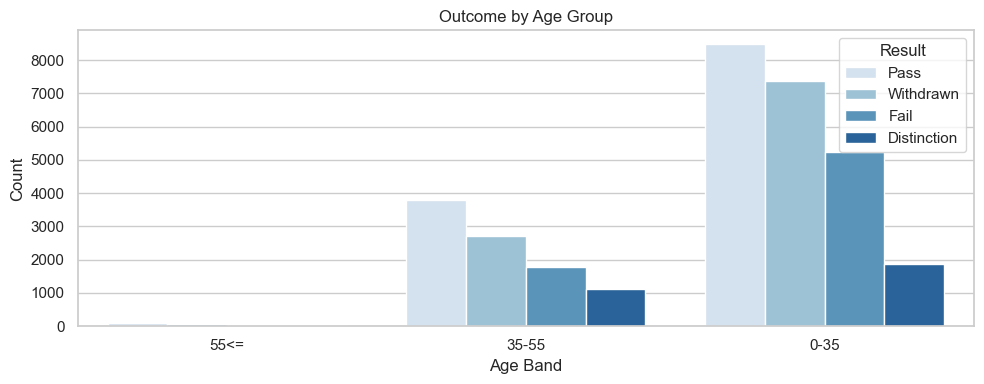

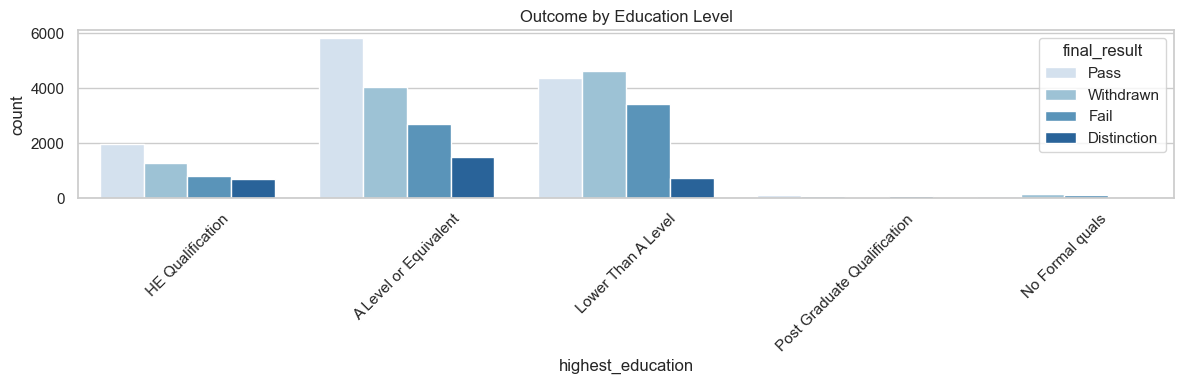

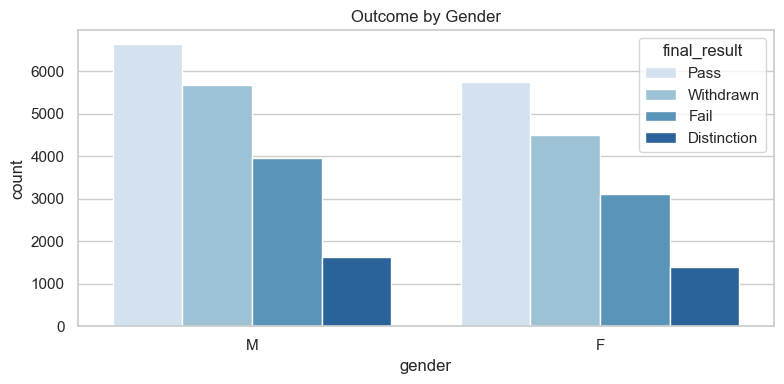

In [6]:
# Age distribution vs outcome
plt.figure(figsize=(10, 4))
sns.countplot(data=students, x='age_band',
              hue='final_result',
              palette='Blues')
plt.title('Outcome by Age Group')
plt.xlabel('Age Band')
plt.ylabel('Count')
plt.legend(title='Result')
plt.tight_layout()
plt.show()

# Education level vs outcome
plt.figure(figsize=(12, 4))
sns.countplot(data=students, x='highest_education',
              hue='final_result',
              palette='Blues')
plt.title('Outcome by Education Level')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Gender vs outcome
plt.figure(figsize=(8, 4))
sns.countplot(data=students, x='gender',
              hue='final_result',
              palette='Blues')
plt.title('Outcome by Gender')
plt.tight_layout()
plt.show()

/var/folders/78/fp6ycqwd4n33yk56_4fqw4w00000gn/T/ipykernel_94873/544882220.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=students, x='final_result',
/var/folders/78/fp6ycqwd4n33yk56_4fqw4w00000gn/T/ipykernel_94873/544882220.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=students, x='final_result',


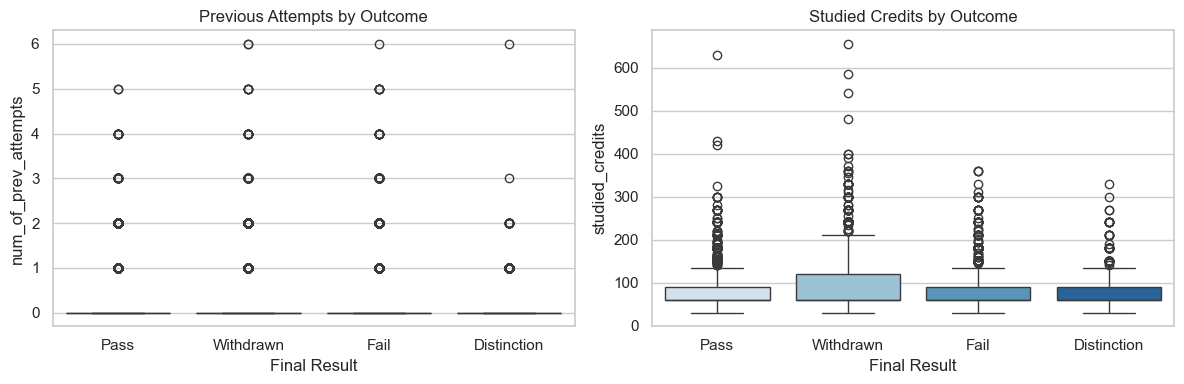

In [7]:
# Distribution of numerical features
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Previous attempts
sns.boxplot(data=students, x='final_result', 
            y='num_of_prev_attempts',
            palette='Blues',
            ax=axes[0])
axes[0].set_title('Previous Attempts by Outcome')
axes[0].set_xlabel('Final Result')

# Studied credits
sns.boxplot(data=students, x='final_result',
            y='studied_credits',
            palette='Blues',
            ax=axes[1])
axes[1].set_title('Studied Credits by Outcome')
axes[1].set_xlabel('Final Result')

plt.tight_layout()
plt.show()

/var/folders/78/fp6ycqwd4n33yk56_4fqw4w00000gn/T/ipykernel_94873/3347458683.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=students_vle, x='final_result',


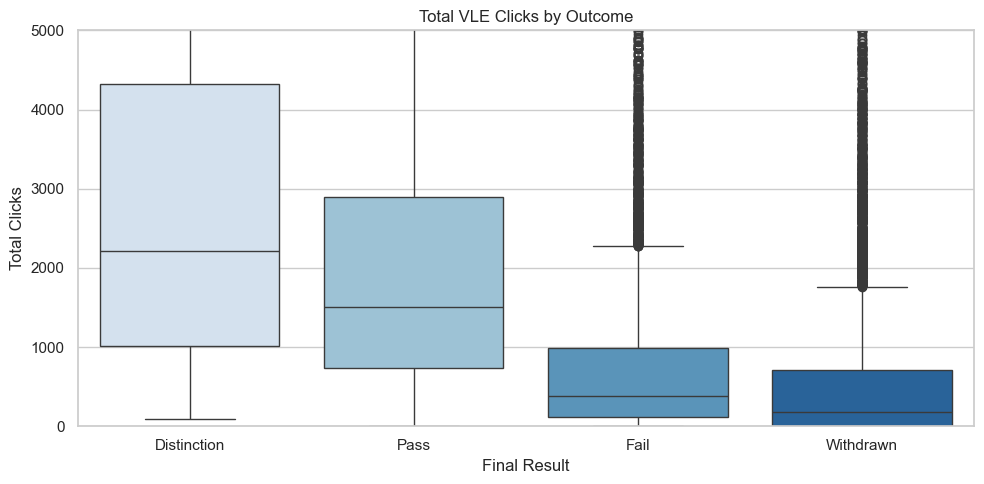

Median clicks per outcome:
final_result
Distinction    2218.0
Pass           1503.0
Fail            387.0
Withdrawn       178.0
Name: total_clicks, dtype: float64


In [8]:
# Total clicks per student
vle_summary = student_vle.groupby('id_student')['sum_click'].sum().reset_index()
vle_summary.columns = ['id_student', 'total_clicks']

# Merge with student outcomes
students_vle = students.merge(vle_summary, on='id_student', how='left')
students_vle['total_clicks'] = students_vle['total_clicks'].fillna(0)

# Plot
plt.figure(figsize=(10, 5))
sns.boxplot(data=students_vle, x='final_result',
            y='total_clicks',
            palette='Blues',
            order=['Distinction', 'Pass', 'Fail', 'Withdrawn'])
plt.title('Total VLE Clicks by Outcome')
plt.xlabel('Final Result')
plt.ylabel('Total Clicks')
plt.ylim(0, 5000)
plt.tight_layout()
plt.show()

# Print median clicks per outcome
print("Median clicks per outcome:")
print(students_vle.groupby('final_result')['total_clicks'].median().sort_values(ascending=False))

In [9]:
# Save a summary of what we found
print("=== EDA Summary ===")
print(f"Total students: {students.shape[0]}")
print(f"\nOutcome distribution:")
print(students['final_result'].value_counts())
print(f"\nMedian clicks by outcome:")
print(students_vle.groupby('final_result')['total_clicks'].median().sort_values(ascending=False))

=== EDA Summary ===
Total students: 32593

Outcome distribution:
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

Median clicks by outcome:
final_result
Distinction    2218.0
Pass           1503.0
Fail            387.0
Withdrawn       178.0
Name: total_clicks, dtype: float64
